### `Chain Of Thoughts with RAG`

What is Chain-of-Thought (CoT) in RAG?
CoT reasoning breaks down a complex question into intermediate steps and allows retrieval + reflection at each step before answering.

Using Query:
- `Step 1`: Break question -> Sub-question (Reason)
- `Step 2`: Retrieve docs per step (Act)
- `Step 3`: Combine or Merge all docs (Observe)
- `Step 4`: Final - Generation Answer (Reflect)

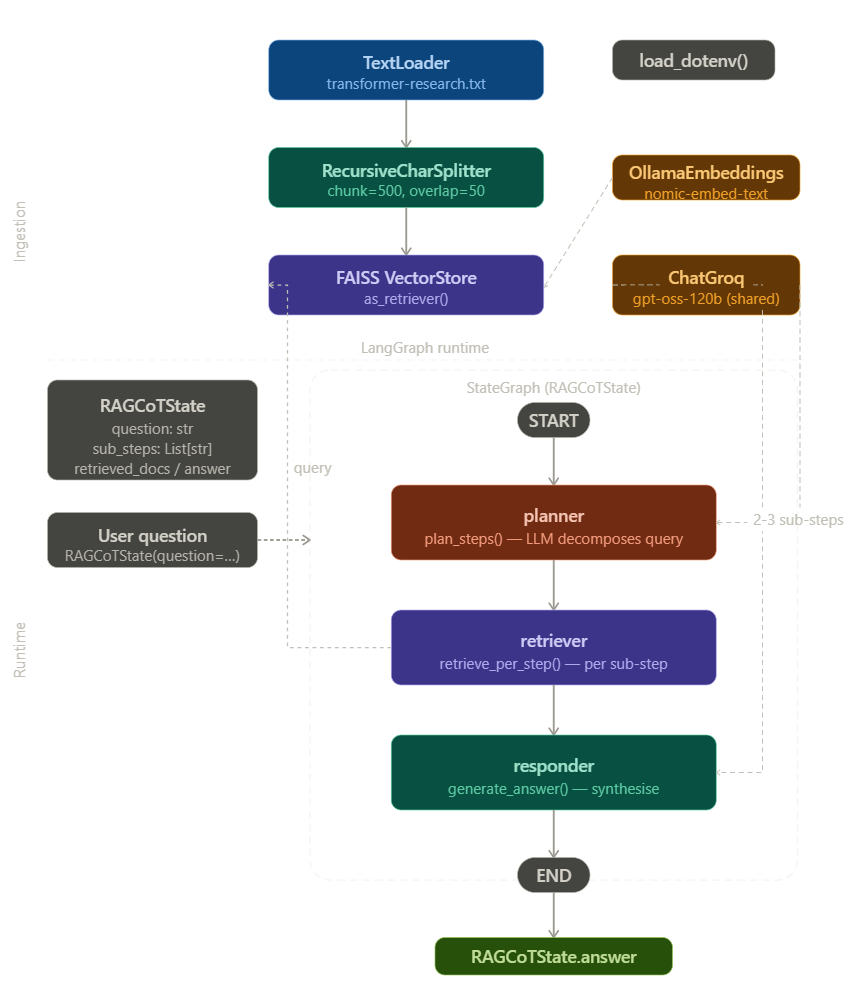

In [1]:
# ------------------------------------------------------------
# 1. Load Text File, Embeddings, Vector Store and LLM 
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

docs = TextLoader('data/transformer-research.txt', encoding='utf-8').load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')

vector_db = FAISS.from_documents(chunks, embedding)
retriever = vector_db.as_retriever()

llm = ChatGroq(model='openai/gpt-oss-120b')

In [2]:
# ------------------------------------------------------------
# 2. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document

class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ''

In [3]:
# ------------------------------------------------------------
# 3. Nodes 
# ------------------------------------------------------------

# a) Plan sub-questions
def plan_steps(state: RAGCoTState) -> RAGCoTState:
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = llm.invoke(prompt).content
    sub_questions = [line.strip() for line in result.split('\n') if line.strip()]
    print('⁉️ Sub questions:\n', sub_questions)
    return state.model_copy(update={'sub_steps': sub_questions})

In [4]:
# b) Retrieve for each step
def retrieve_per_step(state: RAGCoTState) -> RAGCoTState:
    all_docs = []
    for sub in state.sub_steps:
        all_docs.extend(retriever.invoke(sub))
    print('📚 Retrieval Documents:\n', all_docs)
    return state.model_copy(update={'retrieved_docs': all_docs})

In [5]:
# c) Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
        You are answering a complex question using reasoning and retrieved documents.
        
        Question: {state.question}
        Relevant Information: {context}
        
        Now synthesis a well-reasoned final answer.
    """
    
    result = llm.invoke(prompt).content.strip()
    print('🤖 Generated Answer:\n', result)
    return state.model_copy(update={'answer': result})

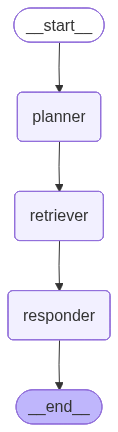

In [6]:
# ------------------------------------------------------------
# 4. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(RAGCoTState)

builder.add_node('planner', plan_steps)
builder.add_node('retriever', retrieve_per_step)
builder.add_node('responder', generate_answer)

builder.set_entry_point('planner')
builder.add_edge('planner', 'retriever')
builder.add_edge('retriever', 'responder')
builder.add_edge('responder', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# ------------------------------------------------------------
# 5. Run CoT RAG Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'What are the additional experiments in Transformer evaluation?'
    state = RAGCoTState(question=query)
    result = graph.invoke(state)
    
    # print('\n Reasoning Steps: ', result['sub_steps'])
    print('\n ✅ Final Answer: \n', result['answer'])

⁉️ Sub questions:
 ['**Step\u202f1 – Identify the baseline evaluation framework**', '- List the core metrics and tasks that are usually reported for a Transformer (e.g., BLEU/ROUGE for translation/summarization, accuracy/F1 for classification, perplexity for language modeling).', '- Note the standard datasets and training‑inference settings that constitute the “baseline” comparison (e.g., WMT\u202f14 EN‑DE, GLUE, ImageNet, etc.).', '**Step\u202f2 – Enumerate the categories of “additional experiments” that researchers typically add on top of the baseline**', '- **Ablation / component analysis** – systematically remove or modify parts of the architecture (e.g., number of heads, depth, positional encodings, dropout) to gauge their impact.', '- **Scaling & efficiency studies** – vary model size, batch size, or compute budget; measure training speed, inference latency, FLOPs, memory usage, and performance‑vs‑size curves.', '- **Robustness & generalisation checks** – test on out‑of‑distribut